# Black Friday Retail Analytics : 
### Data Based Approach To Uncover Insights From Black Friday Sale

Black Friday drives peak transaction volume across a retailer's physical and online channels, and with that scale comes fragmented customer behavior, uneven product demand, and marketing spend that's hard to justify without data. This project turns a 550K-row Black Friday transaction extract into a data-driven view of customer segments, product performance, and campaign strategy for future mega-events.

![Deliverable 4 Roadmap](deliverable_4.png)

### 4.1 Building connecttion with sql db

In [11]:
!pip install python-dotenv

In [12]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [13]:
import os
import warnings
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine, URL

# 1. Load the environment variables from the .env file
load_dotenv()

warnings.filterwarnings('ignore')

# 3. Build the URL by fetching the credentials securely

url = URL.create(
    drivername="mysql+pymysql",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT", 3306)), 
    database=os.getenv("DB_NAME")
)

# 4. Create the database engine
engine = create_engine(url)


data = pd.read_csv("Black Friday Data.csv")
data.to_sql('black_friday_staging', engine, index=False, if_exists='replace', chunksize=5000)

print(f"Rows loaded: {len(data)}")

Rows loaded: 550068


In [14]:
query = """                              
SELECT *
FROM black_friday_data;
"""
# pulling data from actual sales table 

df = pd.read_sql(query, engine)

print(f"Rows loaded: {len(df):,}")
print(f"Columns: {len(df.columns)}")

Rows loaded: 550,068
Columns: 12


### Performing data inspection 

In [15]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00000142,F,0-17,10,A,2,0,3,4.0,5.0,13650
1,1000001,P00004842,F,0-17,10,A,2,0,3,4.0,12.0,13645
2,1000001,P00025442,F,0-17,10,A,2,0,1,2.0,9.0,15416
3,1000001,P00051442,F,0-17,10,A,2,0,8,17.0,NaN,9938
4,1000001,P00051842,F,0-17,10,A,2,0,4,8.0,NaN,2849


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  object 
 2   Gender                      550068 non-null  object 
 3   Age                         550068 non-null  object 
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  object 
 6   Stay_In_Current_City_Years  550068 non-null  object 
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 50.4+ MB


In [17]:
print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())



Shape: (550068, 12)

Data Types:
User_ID                         int64
Product_ID                     object
Gender                         object
Age                            object
Occupation                      int64
City_Category                  object
Stay_In_Current_City_Years     object
Marital_Status                  int64
Product_Category_1              int64
Product_Category_2            float64
Product_Category_3            float64
Purchase                        int64
dtype: object

Missing Values:
User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            173638
Product_Category_3            383247
Purchase                           0
dtype: int64


In [18]:
print("\nDescriptive Statistics:")
print(df.describe())


Descriptive Statistics:
            User_ID     Occupation  Marital_Status  Product_Category_1  \
count  5.500680e+05  550068.000000   550068.000000       550068.000000   
mean   1.003029e+06       8.076707        0.409653            5.404270   
std    1.727592e+03       6.522660        0.491770            3.936211   
min    1.000001e+06       0.000000        0.000000            1.000000   
25%    1.001516e+06       2.000000        0.000000            1.000000   
50%    1.003077e+06       7.000000        0.000000            5.000000   
75%    1.004478e+06      14.000000        1.000000            8.000000   
max    1.006040e+06      20.000000        1.000000           20.000000   

       Product_Category_2  Product_Category_3       Purchase  
count       376430.000000       166821.000000  550068.000000  
mean             9.842329           12.668243    9263.968713  
std              5.086590            4.125338    5023.065394  
min              2.000000            3.000000      12.00

#### Observation :
- This output summarizes a Black Friday sales dataset of 550,068 rows and 12 columns, showing  missingness in secondary/tertiary product categories.
- The average customer purchase amount is approximately 9264 , minimum value is  12 to a maximum of 23,961.

#### Handling Missing Values 
- The Product_Category_2 and Product_Category_3 has missing values because they represent absence of a purchase. Every transaction has a primary product (Category_1), but a customer simply might not have added a second or third item to their cart.
- imputing them with mean/median/mode might alter the actual sales figures , hence choosing to fill with 0 to preserve data intergrity.

In [19]:
df.columns = df.columns.str.strip()
df['Product_Category_2'] = df['Product_Category_2'].fillna(0)
df['Product_Category_3'] = df['Product_Category_3'].fillna(0)

In [20]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Product_Category_2            0
Product_Category_3            0
Purchase                      0
dtype: int64


## 4.2 Overall Sales Performance

In [21]:
#KPIS
kpi_df = pd.DataFrame(
    [
        {"KPI": "Total Sales", "Value": f"{df['Purchase'].sum():,.2f}"},
        {"KPI": "Purchase Records", "Value": f"{df.shape[0]:,}"},
        {"KPI": "Unique Customers", "Value": f"{df['User_ID'].nunique():,}"},
        {"KPI": "Unique Products", "Value": f"{df['Product_ID'].nunique():,}"},
        {"KPI": "Average Purchase", "Value": f"${df['Purchase'].mean():,.2f}"},
        {"KPI": "Median Purchase", "Value": f"${df['Purchase'].median():,.2f}"},
        {"KPI": "Minimum Purchase", "Value": f"${df['Purchase'].min():,.2f}"},
        {"KPI": "Maximum Purchase", "Value": f"${df['Purchase'].max():,.2f}"},
        {"KPI": "Purchase Std Dev", "Value": f"${df['Purchase'].std():,.2f}"},
    ]
)

display(kpi_df)

,KPI,Value
0,Total Sales,"5,095,812,742.00"
1,Purchase Records,"550,068"
2,Unique Customers,"5,891"
3,Unique Products,"3,631"
4,Average Purchase,"$9,263.97"
5,Median Purchase,"$8,047.00"
6,Minimum Purchase,$12.00
7,Maximum Purchase,"$23,961.00"
8,Purchase Std Dev,"$5,023.07"


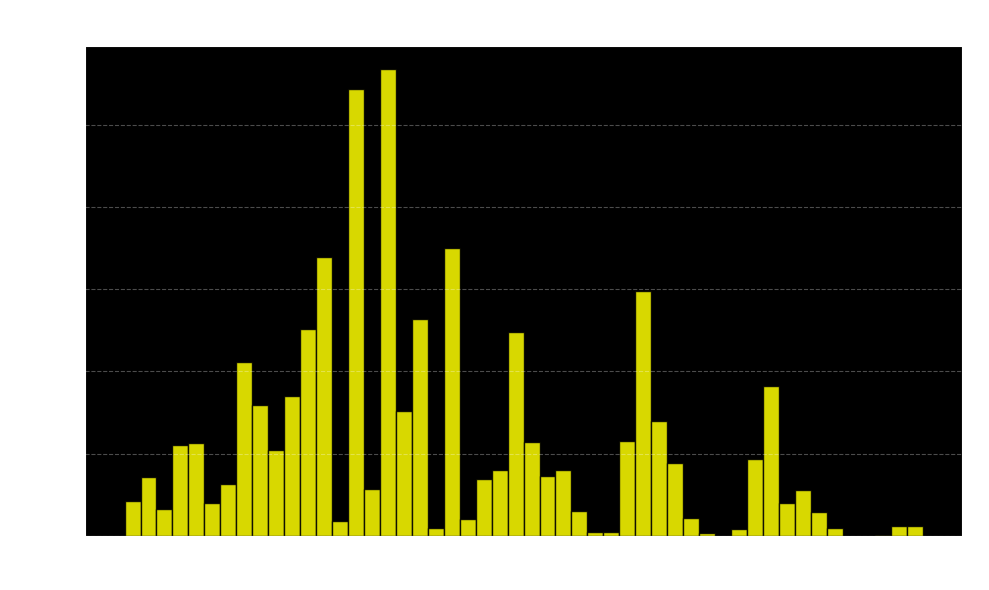

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
plt.style.use("dark_background")
plt.hist(df["Purchase"], bins=50, color="yellow", edgecolor="black", alpha=0.85)

plt.title("Distribution of Purchase Amount", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Purchase Amount", fontsize=12)
plt.ylabel("Number of Purchases", fontsize=12)


plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

#### Observation:
- Black Friday spending concentrated around a particular purchase range i.e. 5k to 10k range. 

## 4.3 Customer Demographics

#### Sales by Gender

In [23]:
gender_analysis = (
    df.groupby("Gender")
      .agg(
          Total_Sales=("Purchase", "sum"),
          Purchase_Records=("Purchase", "count"),
          Average_Purchase=("Purchase", "mean"),
          Unique_Customers=("User_ID", "nunique")
      ).reset_index()
)

#calculate percentage
gender_analysis["Sales_Share_%"] = (
    gender_analysis["Total_Sales"]
    / gender_analysis["Total_Sales"].sum()
    * 100
)

gender_analysis
gender_analysis["Total_Sales"] = (gender_analysis["Total_Sales"] / 1000000000).apply(lambda x: f"{x:.2f}B")
gender_analysis

,Gender,Total_Sales,Purchase_Records,Average_Purchase,Unique_Customers,Sales_Share_%
0,F,1.19B,135809,8734.565765,1666,23.278576
1,M,3.91B,414259,9437.526040,4225,76.721424


#### Age Group Analysis

In [24]:
age_analysis = (
    df.groupby("Age")
      .agg(
          Total_Sales=("Purchase", "sum"),
          Purchase_Records=("Purchase", "count"),
          Average_Purchase=("Purchase", "mean"),
          Unique_Customers=("User_ID", "nunique")
      ).reset_index())




#calculate percentage
age_analysis["Sales_Share_%"] = (
    age_analysis["Total_Sales"]
    / age_analysis["Total_Sales"].sum()
    * 100
)

age_analysis = age_analysis.sort_values(by="Total_Sales", ascending=False)


age_analysis["Total_Sales"] = (age_analysis["Total_Sales"] / 1000000000).apply(lambda x: f"{x:.2f}B")

age_analysis

,Age,Total_Sales,Purchase_Records,Average_Purchase,Unique_Customers,Sales_Share_%
2,26-35,2.03B,219587,9252.690633,2053,39.871374
3,36-45,1.03B,110013,9331.350695,1167,20.145361
1,18-25,0.91B,99660,9169.663606,1069,17.933325
4,46-50,0.42B,45701,9208.625697,531,8.258612
5,51-55,0.37B,38501,9534.808031,481,7.203947
6,55+,0.20B,21504,9336.280459,372,3.939850
0,0-17,0.13B,15102,8933.464640,218,2.647530


In [25]:
marital_analysis = (
    df.groupby("Marital_Status")
      .agg(
          Total_Sales=("Purchase", "sum"),
          Purchase_Records=("Purchase", "count"),
          Average_Purchase=("Purchase", "mean"),
          Unique_Customers=("User_ID", "nunique")
      )) 


marital_analysis["Sales_Share_%"] = (
    marital_analysis["Total_Sales"]
    / marital_analysis["Total_Sales"].sum()
    * 100
)


marital_analysis["Total_Sales"] = (marital_analysis["Total_Sales"] / 1000000).apply(lambda x: f"{x:.2f}M")

# 1 = Married & 0 = Single 

marital_analysis

,Total_Sales,Purchase_Records,Average_Purchase,Unique_Customers,Sales_Share_%
Marital_Status,,,,,
0,3008.93M,324731,9265.907619,3417,59.047057
1,2086.89M,225337,9261.174574,2474,40.952943


In [26]:
print("===== GENDER ANALYSIS =====")
display(gender_analysis)

print("\n===== AGE ANALYSIS =====")
display(age_analysis.sort_values("Total_Sales", ascending=True))

print("\n===== MARITAL STATUS ANALYSIS =====")
display(marital_analysis)

===== GENDER ANALYSIS =====


,Gender,Total_Sales,Purchase_Records,Average_Purchase,Unique_Customers,Sales_Share_%
0,F,1.19B,135809,8734.565765,1666,23.278576
1,M,3.91B,414259,9437.526040,4225,76.721424



===== AGE ANALYSIS =====


,Age,Total_Sales,Purchase_Records,Average_Purchase,Unique_Customers,Sales_Share_%
0,0-17,0.13B,15102,8933.464640,218,2.647530
6,55+,0.20B,21504,9336.280459,372,3.939850
5,51-55,0.37B,38501,9534.808031,481,7.203947
4,46-50,0.42B,45701,9208.625697,531,8.258612
1,18-25,0.91B,99660,9169.663606,1069,17.933325
3,36-45,1.03B,110013,9331.350695,1167,20.145361
2,26-35,2.03B,219587,9252.690633,2053,39.871374



===== MARITAL STATUS ANALYSIS =====


,Total_Sales,Purchase_Records,Average_Purchase,Unique_Customers,Sales_Share_%
Marital_Status,,,,,
0,3008.93M,324731,9265.907619,3417,59.047057
1,2086.89M,225337,9261.174574,2474,40.952943


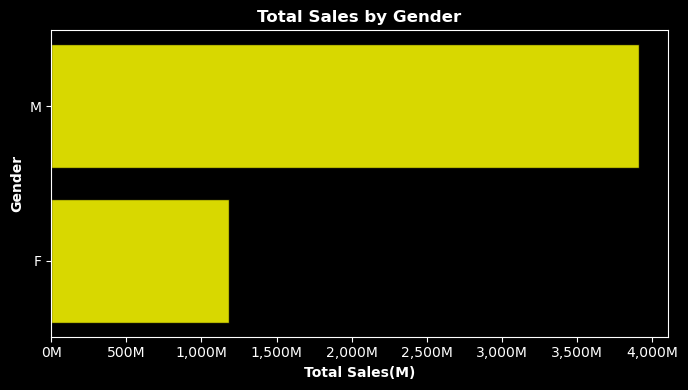

In [27]:
from matplotlib.ticker import FuncFormatter
gender_analysis = df.groupby("Gender")["Purchase"].sum().reset_index()
gender_analysis.columns = ["Gender", "Total_Sales"]


plt.figure(figsize=(7, 4))

plt.barh(
    gender_analysis["Gender"],
    gender_analysis["Total_Sales"],
    color="yellow",
    edgecolor="black",
    alpha=0.85,
)

plt.title("Total Sales by Gender", fontweight="bold")
plt.ylabel("Gender", fontweight="bold")
plt.xlabel("Total Sales(M)", fontweight="bold")
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1e6:,.0f}M"))
    
plt.tight_layout()
plt.show()

### Boxplot  Purchase by Age Group

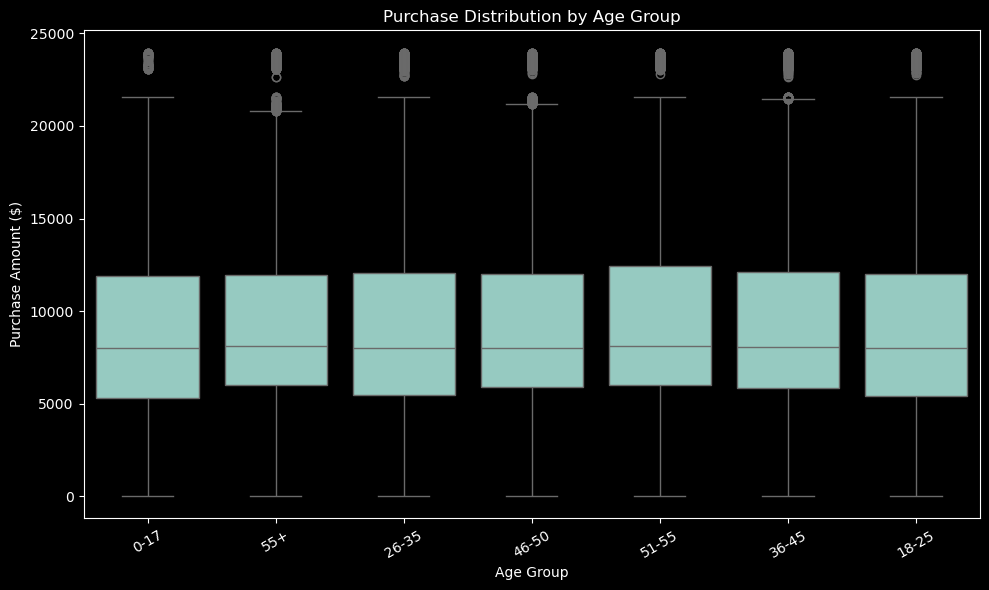

In [28]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=data,
    x='Age',
    y='Purchase'
)

plt.title('Purchase Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Purchase Amount ($)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Boxplot  Purchase by City Category

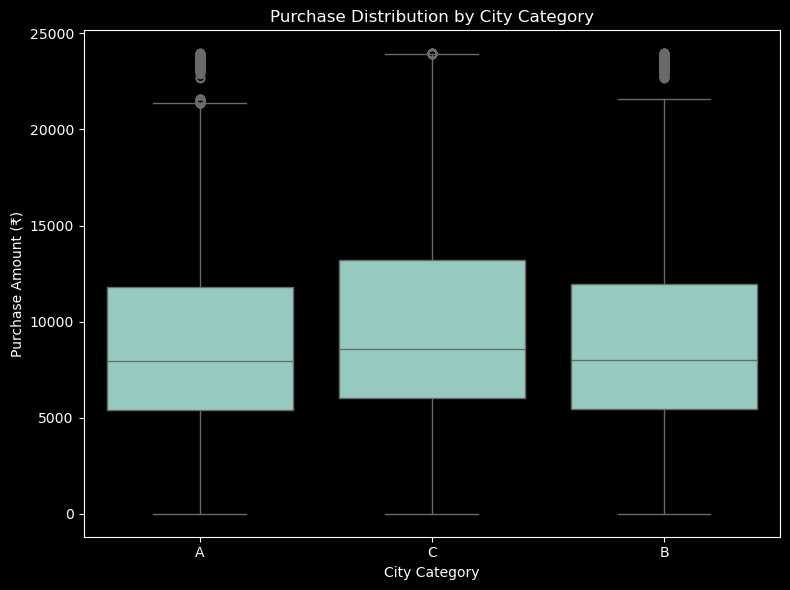

In [29]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=data,
    x='City_Category',
    y='Purchase'
)

plt.title('Purchase Distribution by City Category')
plt.xlabel('City Category')
plt.ylabel('Purchase Amount (₹)')
plt.tight_layout()
plt.show()

### Boxplot  Purchase by Marital Status

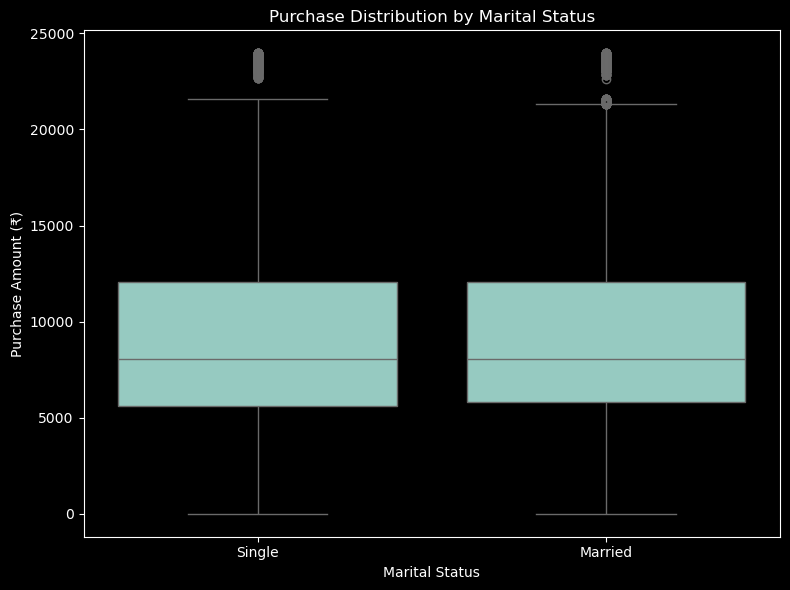

In [30]:
data['Marital_Status_Label'] = data['Marital_Status'].map({
    0: 'Single',
    1: 'Married'
})

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=data,
    x='Marital_Status_Label',
    y='Purchase'
)

plt.title('Purchase Distribution by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Purchase Amount (₹)')
plt.tight_layout()
plt.show()

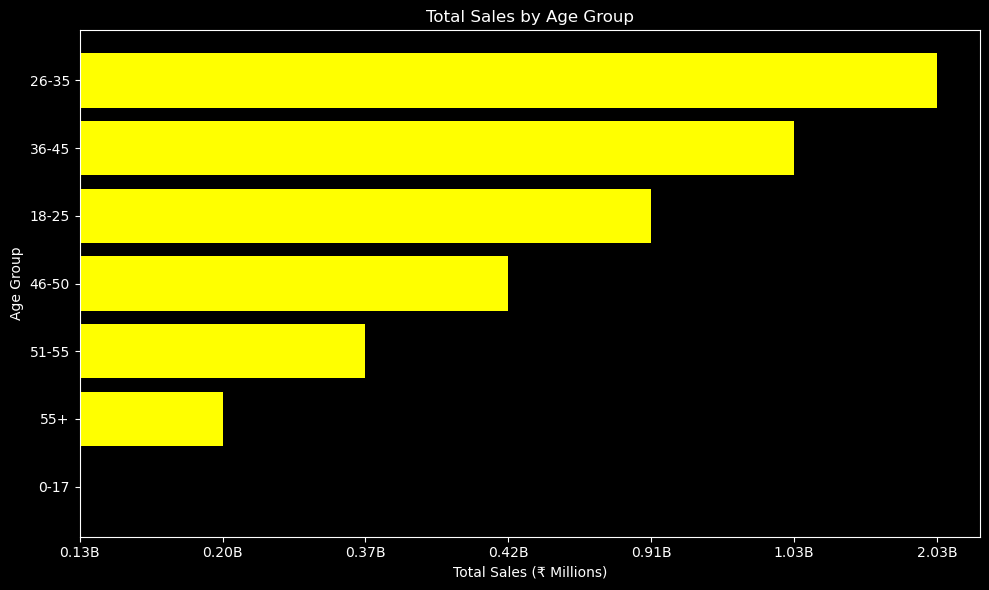

In [31]:
age_chart = age_analysis.sort_values(
    "Total_Sales",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    age_chart["Age"],
    age_chart["Total_Sales"],color = "yellow"
)

plt.title("Total Sales by Age Group")
plt.xlabel("Total Sales (₹ Millions)")
plt.ylabel("Age Group")

plt.tight_layout()
plt.show()

#### Insights:
- Total Black Friday sales amount to approximately 5.10 billion across 550,068 purchase records.
- Male customers contribute 76.72% of total sales, supported by both higher customer participation and a higher average purchase value.
The 26–35 age group is the largest revenue-generating segment, contributing 39.87% of total sales.
Customers aged 26–45 collectively contribute approximately 60% of total sales, making this the core revenue-generating age segment.
- The 51–55 age group has the highest average purchase value at approximately 9,535, despite contributing only 7.20% of total sales.
- Marital Status 0 contributes 59.05% of sales compared with 40.95% for Status 1; however, average purchase values are almost identical, indicating a  primarily volume-driven difference.
- The lower sales contribution from female customers presents an opportunity for deeper investigation into product-category preferences rather than immediately assuming lower demand.

### 4.4  City & Customer Tenure Analysis

In [32]:
city_analysis = (
    df.groupby("City_Category")
      .agg(
          Total_Sales=("Purchase", "sum"),
          Purchase_Records=("Purchase", "count"),
          Unique_Customers=("User_ID", "nunique"),
          Average_Purchase=("Purchase", "mean")
      ).reset_index())

city_analysis["Sales_Share_%"] = (
    city_analysis["Total_Sales"]
    / city_analysis["Total_Sales"].sum()
    * 100)

city_analysis = city_analysis.sort_values(
    "Total_Sales",
    ascending=False)
city_analysis["Total_Sales"] = (city_analysis["Total_Sales"] / 1000000000).apply(lambda x: f"{x:.2f}B")
city_analysis["Average_Purchase"] = (city_analysis["Average_Purchase"] ).apply(lambda x: f"{x:.2f}")
city_analysis

,City_Category,Total_Sales,Purchase_Records,Unique_Customers,Average_Purchase,Sales_Share_%
1,B,2.12B,231173,1707,9151.30,41.515136
2,C,1.66B,171175,3139,9719.92,32.650483
0,A,1.32B,147720,1045,8911.94,25.834381


In [33]:
print(city_analysis.columns)

Index(['City_Category', 'Total_Sales', 'Purchase_Records', 'Unique_Customers',
       'Average_Purchase', 'Sales_Share_%'],
      dtype='object')


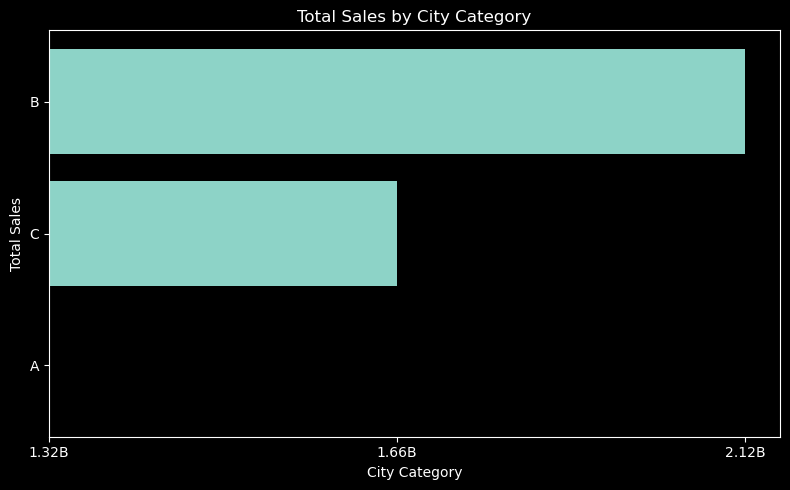

In [34]:
city_analysis = city_analysis.sort_values(
    "Total_Sales",
    ascending=True)

plt.figure(figsize=(8, 5))

plt.barh(
    city_analysis["City_Category"],
    city_analysis["Total_Sales"]
)

plt.title("Total Sales by City Category")
plt.xlabel("City Category")
plt.ylabel("Total Sales")



plt.tight_layout()
plt.show()

#### Customer Tenure

In [35]:
tenure_analysis = (
    df.groupby("Stay_In_Current_City_Years")
      .agg(
          Total_Sales=("Purchase", "sum"),
          Purchase_Records=("Purchase", "count"),
          Unique_Customers=("User_ID", "nunique"),
          Average_Purchase=("Purchase", "mean")
      )
      .reset_index()
)

tenure_analysis["Sales_Share_%"] = (
    tenure_analysis["Total_Sales"]
    / tenure_analysis["Total_Sales"].sum()
    * 100
)

tenure_analysis["Total_Sales"] = (tenure_analysis["Total_Sales"] / 1000000000).apply(lambda x: f"{x:.2f}B")
tenure_analysis["Average_Purchase"] = (tenure_analysis["Average_Purchase"] ).apply(lambda x: f"{x:.2f}")
tenure_analysis = tenure_analysis.sort_values(
    "Total_Sales",
    ascending=False)
tenure_analysis


,Stay_In_Current_City_Years,Total_Sales,Purchase_Records,Unique_Customers,Average_Purchase,Sales_Share_%
1,1,1.79B,193821,2086,9250.15,35.183250
2,2,0.95B,101838,1145,9320.43,18.626547
3,3,0.88B,95285,979,9286.90,17.365290
4,4+,0.79B,84726,909,9275.60,15.422160
0,0,0.68B,74398,772,9180.08,13.402754


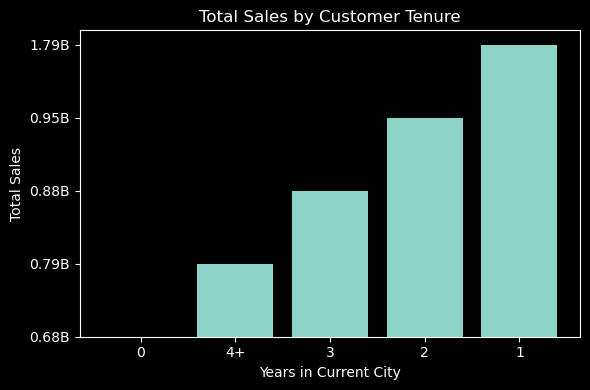

In [36]:
tenure_analysis = tenure_analysis.sort_values(
    "Total_Sales",
    ascending=True)
plt.figure(figsize=(6,4))

plt.bar(
    tenure_analysis["Stay_In_Current_City_Years"],
    tenure_analysis["Total_Sales"]
)

plt.title("Total Sales by Customer Tenure")
plt.xlabel("Years in Current City")
plt.ylabel("Total Sales")


plt.tight_layout()
plt.show()

#### 4.5 Occupation Analysis

In [37]:
occupation_analysis = (
    df.groupby("Occupation")
      .agg(
          Total_Sales=("Purchase", "sum"),
          Purchase_Records=("Purchase", "count"),
          Unique_Customers=("User_ID", "nunique"),
          Average_Purchase=("Purchase", "mean") ).reset_index())

occupation_analysis["Sales_Share_%"] = (
    occupation_analysis["Total_Sales"]
    / occupation_analysis["Total_Sales"].sum()
    * 100)



occupation_analysis["Total_Sales"] = (occupation_analysis["Total_Sales"] / 1000000000).apply(lambda x: f"{x:.2f}B")
occupation_analysis["Average_Purchase"] = (occupation_analysis["Average_Purchase"] ).apply(lambda x: f"{x:.2f}")

occupation_analysis = occupation_analysis.sort_values(
    "Total_Sales",
    ascending=False
)

occupation_analysis

,Occupation,Total_Sales,Purchase_Records,Unique_Customers,Average_Purchase,Sales_Share_%
4,4,0.67B,72308,740,9213.98,13.074352
0,0,0.64B,69638,688,9124.43,12.469198
7,7,0.56B,59133,669,9425.73,10.937835
1,1,0.42B,47426,517,8953.19,8.332609
17,17,0.39B,40043,491,9821.48,7.717738
12,12,0.31B,31179,376,9796.64,5.994126
20,20,0.30B,33562,273,8836.49,5.819885
14,14,0.26B,27309,294,9500.70,5.091527
16,16,0.24B,25371,235,9394.46,4.677310
2,2,0.24B,26588,256,8952.48,4.671062


In [38]:
top_10_occupations = occupation_analysis.head(10)

top_10_occupations

,Occupation,Total_Sales,Purchase_Records,Unique_Customers,Average_Purchase,Sales_Share_%
4,4,0.67B,72308,740,9213.98,13.074352
0,0,0.64B,69638,688,9124.43,12.469198
7,7,0.56B,59133,669,9425.73,10.937835
1,1,0.42B,47426,517,8953.19,8.332609
17,17,0.39B,40043,491,9821.48,7.717738
12,12,0.31B,31179,376,9796.64,5.994126
20,20,0.30B,33562,273,8836.49,5.819885
14,14,0.26B,27309,294,9500.70,5.091527
16,16,0.24B,25371,235,9394.46,4.677310
2,2,0.24B,26588,256,8952.48,4.671062


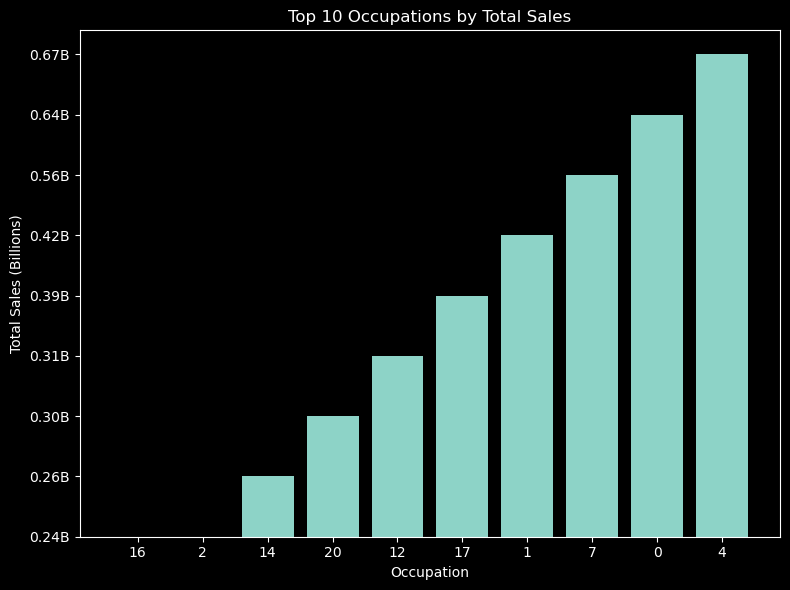

In [39]:
top_10_occupations = top_10_occupations.sort_values(
    "Total_Sales",
    ascending=True
)

plt.figure(figsize=(8, 6))

plt.bar(
    top_10_occupations["Occupation"].astype(str),
    top_10_occupations["Total_Sales"]
)

plt.title("Top 10 Occupations by Total Sales")
plt.ylabel("Total Sales (Billions)")
plt.xlabel("Occupation")



plt.tight_layout()
plt.show()

 **Checking for Unique Customers occupation wise**

In [40]:
occupation_analysis.sort_values(
    "Unique_Customers",
    ascending=False
).head(10)

,Occupation,Total_Sales,Purchase_Records,Unique_Customers,Average_Purchase,Sales_Share_%
4,4,0.67B,72308,740,9213.98,13.074352
0,0,0.64B,69638,688,9124.43,12.469198
7,7,0.56B,59133,669,9425.73,10.937835
1,1,0.42B,47426,517,8953.19,8.332609
17,17,0.39B,40043,491,9821.48,7.717738
12,12,0.31B,31179,376,9796.64,5.994126
14,14,0.26B,27309,294,9500.70,5.091527
20,20,0.30B,33562,273,8836.49,5.819885
2,2,0.24B,26588,256,8952.48,4.671062
16,16,0.24B,25371,235,9394.46,4.677310


#### City
- City B gives the highest total sales with 41.52% and is the major source of revenues among all other city segments.
- City C is the city with the highest average purchase value at 9,719.92; although it has low total sales compared to City B, it has high purchase value.
- City C has the highest number of unique customers, while City B has the highest transaction number which means that there is a difference in purchasing frequency between the two cities.
#### Customer Tenure
- One year tenure for city customers results in the highest sales percentage contribution with 35.18%.
- The average purchase values are almost the same for all tenure periods which mean that tenure has more impact on the transaction/customer number than the average purchase value, later we can test this using spearman corr.
### Occupation
- Occupation 4 gives the highest occupation sales with 13.07%, Occupation 0, and Occupation 7 follow.
- The three major occupations contribute to about 36.5% of the total sales.
- Occupation 17 has higher average purchase value compared to the sales-generating occupations.

**We Can Seggregate Two Types of High value generating groups**

#### Volume-driven segments
These generate large amounts of revenue because there are many transactions/customers.
eg.
- City B
- Age 26–35
- Occupation 4
- Tenure 1 year

#### High-value segments
These have higher average purchase values.
eg.
- City C
- Age 51–55
- Occupation 17
- Occupation 12

## 4.6  Product Category Analysis

**Product Category 1 Analysis**

In [41]:
category1_analysis = (
    df.groupby("Product_Category_1")
      .agg(
          Total_Sales=("Purchase", "sum"),
          Purchase_Records=("Purchase", "count"),
          Unique_Customers=("User_ID", "nunique"),
          Average_Purchase=("Purchase", "mean")
      )
      .reset_index()
)

category1_analysis["Sales_Share_%"] = (
    category1_analysis["Total_Sales"]
    / category1_analysis["Total_Sales"].sum()
    * 100
)

category1_analysis = category1_analysis.sort_values(
    "Total_Sales",
    ascending=False
)


category1_analysis["Total_Sales"] = (category1_analysis["Total_Sales"] / 1000000).apply(lambda x: f"{x:.2f}M")
category1_analysis["Average_Purchase"] = (category1_analysis["Average_Purchase"] ).apply(lambda x: f"{x:.2f}")

category1_analysis

,Product_Category_1,Total_Sales,Purchase_Records,Unique_Customers,Average_Purchase,Sales_Share_%
0,1,1910.01M,140378,5767,13606.22,37.482024
4,5,941.84M,150933,5751,6240.09,18.482532
7,8,854.32M,113925,5659,7498.96,16.765114
5,6,324.15M,20466,4085,15838.48,6.361111
1,2,268.52M,23864,4296,11251.94,5.269350
2,3,204.08M,20213,3838,10096.71,4.004949
15,16,145.12M,9828,3130,14766.04,2.847840
10,11,113.79M,24287,3583,4685.27,2.233032
9,10,100.84M,5125,2328,19675.57,1.978827
14,15,92.97M,6290,2440,14780.45,1.824420


In [42]:
# TOP 5 products in prod category 1 (total sale wise)
category1_analysis.sort_values(
    "Total_Sales",
    ascending=False
).head(5)

,Product_Category_1,Total_Sales,Purchase_Records,Unique_Customers,Average_Purchase,Sales_Share_%
4,5,941.84M,150933,5751,6240.09,18.482532
14,15,92.97M,6290,2440,14780.45,1.824420
17,18,9.29M,3125,1284,2972.86,0.182310
7,8,854.32M,113925,5659,7498.96,16.765114
6,7,60.90M,3721,1461,16365.69,1.195035


In [43]:
# top 5 accoring to avg purchases
category1_analysis.sort_values(
    "Average_Purchase",  
    ascending=False
).head(5)

,Product_Category_1,Total_Sales,Purchase_Records,Unique_Customers,Average_Purchase,Sales_Share_%
7,8,854.32M,113925,5659,7498.96,16.765114
12,13,4.01M,5549,2272,722.40,0.078665
4,5,941.84M,150933,5751,6240.09,18.482532
10,11,113.79M,24287,3583,4685.27,2.233032
19,20,0.94M,2550,2550,370.48,0.018539


In [44]:
category1_analysis.sort_values(
    "Unique_Customers",                         # TOP 5 by unique cust
    ascending=False
).head(5)

,Product_Category_1,Total_Sales,Purchase_Records,Unique_Customers,Average_Purchase,Sales_Share_%
0,1,1910.01M,140378,5767,13606.22,37.482024
4,5,941.84M,150933,5751,6240.09,18.482532
7,8,854.32M,113925,5659,7498.96,16.765114
1,2,268.52M,23864,4296,11251.94,5.269350
5,6,324.15M,20466,4085,15838.48,6.361111


#### Product Category 2 & 3

In [45]:
category2_analysis = (
    df.dropna(subset=["Product_Category_2"])
      .groupby("Product_Category_2")
      .agg(
          Total_Sales=("Purchase", "sum"),
          Purchase_Records=("Purchase", "count"),
          Unique_Customers=("User_ID", "nunique"),
          Average_Purchase=("Purchase", "mean")
      ).reset_index())

category2_analysis["Sales_Share_%"] = (
    category2_analysis["Total_Sales"]
    / category2_analysis["Total_Sales"].sum()
    * 100)

category2_analysis.sort_values("Total_Sales", ascending = False)


,Product_Category_2,Total_Sales,Purchase_Records,Unique_Customers,Average_Purchase,Sales_Share_%
0,0.0,1305531230,173638,5863,7518.695389,25.619686
1,2.0,670303864,49217,5164,13619.356401,13.154013
7,8.0,658392656,64088,5620,10273.259518,12.920268
15,16.0,445339722,43255,5132,10295.681933,8.739327
14,15.0,392067176,37855,4810,10357.077691,7.693909
13,14.0,391556939,55108,5270,7105.264916,7.683896
3,4.0,262295485,25677,4113,10215.192001,5.147275
4,5.0,236844899,26235,4576,9027.821574,4.647834
5,6.0,189417477,16466,4124,11503.551379,3.717120
10,11.0,126366165,14134,3772,8940.580515,2.479804


In [46]:
category3_analysis = (
    df.dropna(subset=["Product_Category_3"])
      .groupby("Product_Category_3")
      .agg(
          Total_Sales=("Purchase", "sum"),
          Purchase_Records=("Purchase", "count"),
          Unique_Customers=("User_ID", "nunique"),
          Average_Purchase=("Purchase", "mean")
      ).reset_index())

category3_analysis["Sales_Share_%"] = (
    category3_analysis["Total_Sales"]
    / category3_analysis["Total_Sales"].sum()
    * 100)

category3_analysis.sort_values(
    "Total_Sales",
    ascending=False)

,Product_Category_3,Total_Sales,Purchase_Records,Unique_Customers,Average_Purchase,Sales_Share_%
0,0.0,3150994343,383247,5891,8221.836943,61.834971
13,16.0,391040983,32636,5009,11981.890642,7.673771
12,15.0,345662769,28013,4248,12339.369900,6.783271
3,5.0,201858094,16658,4246,12117.786889,3.961254
14,17.0,196581588,16702,4473,11769.943001,3.857708
11,14.0,185249212,18428,4333,10052.594530,3.635322
5,8.0,163619031,12562,4140,13024.918882,3.210853
6,9.0,120788622,11579,3563,10431.697210,2.370350
9,12.0,80583631,9246,2898,8715.512762,1.581370
10,13.0,71977563,5459,2640,13185.118703,1.412484


#### Gender × Product Category

In [47]:
gender_category = (
    df.groupby(
        ["Gender", "Product_Category_1"]
    )
    .agg(
        Total_Sales=("Purchase", "sum"),
        Purchase_Records=("Purchase", "count"),
        Unique_Customers=("User_ID", "nunique"),
        Average_Purchase=("Purchase", "mean")
    ).reset_index())

gender_category_ranked = (
    gender_category
    .sort_values(
        ["Gender", "Total_Sales"],
        ascending=[True, False] ))

gender_category_ranked

,Gender,Product_Category_1,Total_Sales,Purchase_Records,Unique_Customers,Average_Purchase
0,F,1,337631145,24831,1593,13597.162619
4,F,5,264658078,41961,1638,6307.239532
7,F,8,251682476,33558,1614,7499.924787
5,F,6,71104116,4559,1090,15596.428164
1,F,2,64543617,5658,1146,11407.496819
2,F,3,61637516,6006,1093,10262.656677
15,F,16,35264942,2402,816,14681.491257
9,F,10,22882193,1162,513,19692.076592
10,F,11,22161326,4739,867,4676.371808
6,F,7,15460347,943,351,16394.853659


TOP 5 

In [48]:
gender_category_ranked.groupby("Gender").head(5)

,Gender,Product_Category_1,Total_Sales,Purchase_Records,Unique_Customers,Average_Purchase
0,F,1,337631145,24831,1593,13597.162619
4,F,5,264658078,41961,1638,6307.239532
7,F,8,251682476,33558,1614,7499.924787
5,F,6,71104116,4559,1090,15596.428164
1,F,2,64543617,5658,1146,11407.496819
20,M,1,1572382609,115547,4174,13608.164721
24,M,5,677177151,108972,4113,6214.230729
27,M,8,602636323,80367,4045,7498.554419
25,M,6,253046186,15907,2995,15907.851009
21,M,2,203972569,18206,3150,11203.590520


#### Age × Product Category

In [49]:
age_category = (
    df.groupby(
        ["Age", "Product_Category_1"]
    )
    .agg(
        Total_Sales=("Purchase", "sum"),
        Purchase_Records=("Purchase", "count"),
        Unique_Customers=("User_ID", "nunique"),
        Average_Purchase=("Purchase", "mean")
    ) .reset_index())

age_category_ranked = (
    age_category
    .sort_values(
        ["Age", "Total_Sales"],
        ascending=[True, False]))

#TOP 5 product category seggregated by age group 

age_category_ranked.groupby("Age").head(5)

,Age,Product_Category_1,Total_Sales,Purchase_Records,Unique_Customers,Average_Purchase
0,0-17,1,48783247,3585,211,13607.600279
4,0-17,5,27059712,4330,208,6249.356120
7,0-17,8,17234789,2258,200,7632.767493
2,0-17,3,11317806,1200,171,9431.505000
1,0-17,2,8735846,805,160,10851.982609
20,18-25,1,362607972,26962,1053,13448.852904
24,18-25,5,175198782,28522,1050,6142.584040
27,18-25,8,132320061,17911,1022,7387.642287
25,18-25,6,59116571,3749,753,15768.623900
21,18-25,2,48560733,4428,769,10966.741870


HEATMAP

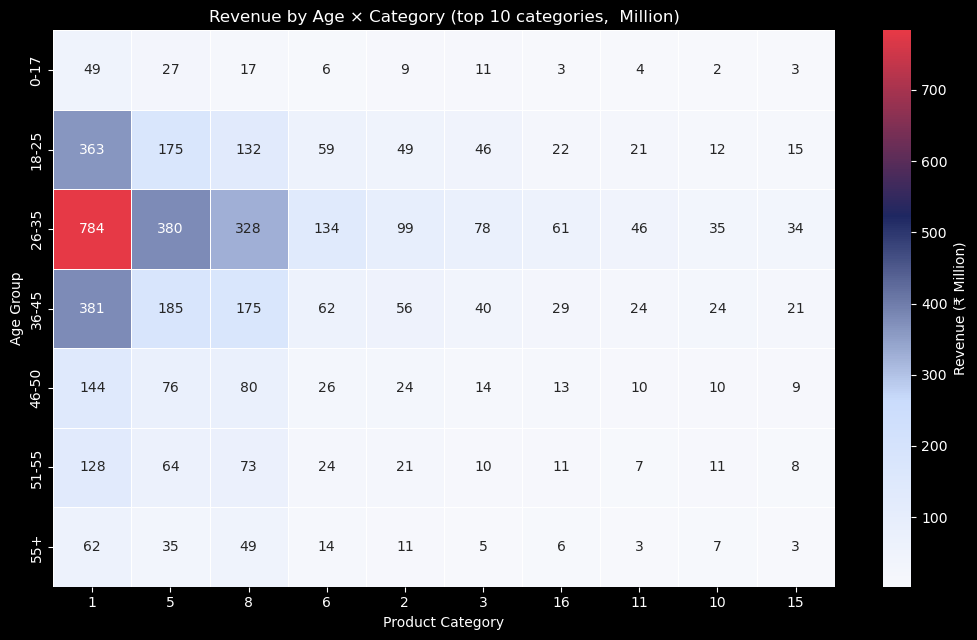

In [50]:
from matplotlib.colors import LinearSegmentedColormap

colormap = LinearSegmentedColormap.from_list('color', ['#F7F8FC', '#CADCFC', '#1E2761', '#E63946'])

age_order = ['0-17','18-25','26-35','36-45','46-50','51-55','55+']
top_cats = df.groupby('Product_Category_1')['Purchase'].sum().sort_values(ascending=False).head(10).index.tolist()

pivot = df.pivot_table(index='Age', columns='Product_Category_1', values='Purchase',
                        aggfunc='sum').reindex(age_order)[top_cats]
pivot_m = pivot / 1e6   # million

fig, ax = plt.subplots(figsize=(10.5, 6.5))
sns.heatmap(pivot_m, annot=True, fmt='.0f', cmap=colormap, linewidths=0.6, linecolor='white',
            cbar_kws={'label': 'Revenue (₹ Million)'}, ax=ax)
ax.set_title('Revenue by Age × Category (top 10 categories,  Million)')
ax.set_xlabel('Product Category'); ax.set_ylabel('Age Group')
plt.tight_layout()
plt.show()

### Observations: 

#### Product Category Performance
- Product Category 1 is highly concentrated, Category 1 along with Categories 5 and 8 together making up about 72.7 per cent of the sales in the Category 1 area.
- The category known as Category 1 brings in the highest revenue, amounting to ₹1.91B and accounting for 37.48 per cent of total sales.
- Categories 6, 7 and 10 have relatively high average purchase values even though they make a substantially smaller contribution to total sales, which shows that there are potential high-value/low-volume opportunities.
- Category 10 records the highest average purchase among Product Category 1 segments at approximately 19,676, but contributes only 1.98% of sales.
- The categories classified as Category 2 and Category 3 also show a high degree of sales concentration, the top-selling categories in each case taking up a large portion of the sales at the category level.
  
#### Gender × Category
- Both male and female customers show a similar pattern when it comes to their preference for different product categories, with categories 1, 5 and 8 always ranking as some of the top contributors to sales.
- The fact that men and women show similar preferences for different categories indicates that it would be better to use category-level targeting with demographic personalization than to adopt entirely separate product strategies for each gender.
#### Age × Category
- The age group ranging from 26 to 35 is the one that produces the most revenue, with their sales mainly focused on Categories 1, 5 and 8.
- In numerous age groups, categories 1, 5 and 8 continue to serve as major factors in sales, showing that they have wide customer appeal.
- The Category 6 has a fairly high average purchase value for both sexes and among various age groups, which means it could be considered for premium positioning or for analysis of upselling.

### 4.7 Customer Segmentation

Customer-Level Dataset

In [51]:
customer_analysis = (
    df.groupby("User_ID")
      .agg(
          Total_Spend=("Purchase", "sum"),
          Purchase_Count=("Purchase", "count"),
          Average_Purchase=("Purchase", "mean")).reset_index())
customer_analysis.head()

,User_ID,Total_Spend,Purchase_Count,Average_Purchase
0,1000001,334093,35,9545.514286
1,1000002,810472,77,10525.610390
2,1000003,341635,29,11780.517241
3,1000004,206468,14,14747.714286
4,1000005,821001,106,7745.292453


Customer Spending Distribution

In [52]:
customer_analysis["Total_Spend"].describe()

count    5.891000e+03
mean     8.650166e+05
std      9.436445e+05
min      4.668100e+04
25%      2.376780e+05
50%      5.212130e+05
75%      1.119250e+06
max      1.053691e+07
Name: Total_Spend, dtype: float64

In [53]:
customer_analysis["CLV"] = (
    customer_analysis["Total_Spend"]
    / customer_analysis["Purchase_Count"])

Creating Customer Segments

Logic used : 
- High Value = Top 25% of customers by total spend.
- Medium Value = Middle 50%.
- Low Value = Bottom 25%.

In [54]:
q25 = customer_analysis["Total_Spend"].quantile(0.25)
q75 = customer_analysis["Total_Spend"].quantile(0.75)

def customer_segment(spend):
    if spend >= q75:
        return "High Value"
    elif spend >= q25:
        return "Medium Value"
    else:
        return "Low Value"

customer_analysis["Customer_Segment"] = (customer_analysis["Total_Spend"].apply(customer_segment))

Segment Analysis

In [55]:
segment_analysis = (
    customer_analysis
    .groupby("Customer_Segment")
    .agg(
        Customers=("User_ID", "nunique"),
        Total_Sales=("Total_Spend", "sum"),
        Total_Purchases=("Purchase_Count", "sum"),
        Average_CLV=("CLV", "mean"),
        Average_Purchase=("Average_Purchase", "mean")
    ).reset_index())

In [56]:
segment_analysis["Sales_Share_%"] = (
    segment_analysis["Total_Sales"]
    / segment_analysis["Total_Sales"].sum()
    * 100
)

segment_analysis["Total_Sales"] = (segment_analysis["Total_Sales"] / 1000000).apply(lambda x: f"{x:.2f}M")
segment_analysis["Average_Purchase"] = (segment_analysis["Average_Purchase"] ).apply(lambda x: f"{x:.2f}")

In [57]:
segment_analysis

,Customer_Segment,Customers,Total_Sales,Total_Purchases,Average_CLV,Average_Purchase,Sales_Share_%
0,High Value,1473,3182.61M,348013,9494.907283,9494.91,62.455390
1,Low Value,1473,235.12M,26815,8975.698149,8975.70,4.614007
2,Medium Value,2945,1678.08M,175240,9902.490367,9902.49,32.930603


#### Identification Of  High-Value Customers 

In [58]:
customer_profile = (
    df.groupby("User_ID")
      .agg(
          Gender=("Gender", "first"),
          Age=("Age", "first"),
          City_Category=("City_Category", "first"),
          Marital_Status=("Marital_Status", "first"),
          Occupation=("Occupation", "first"),
          Stay_In_Current_City_Years=("Stay_In_Current_City_Years", "first")) .reset_index())

In [59]:
customer_analysis = customer_analysis.merge(customer_profile,on="User_ID",how="left")

In [60]:
customer_analysis.head()

,User_ID,Total_Spend,Purchase_Count,Average_Purchase,CLV,Customer_Segment,Gender,Age,City_Category,Marital_Status,Occupation,Stay_In_Current_City_Years
0,1000001,334093,35,9545.514286,9545.514286,Medium Value,F,0-17,A,0,10,2
1,1000002,810472,77,10525.610390,10525.610390,Medium Value,M,55+,C,0,16,4+
2,1000003,341635,29,11780.517241,11780.517241,Medium Value,M,26-35,A,0,15,3
3,1000004,206468,14,14747.714286,14747.714286,Low Value,M,46-50,B,1,7,2
4,1000005,821001,106,7745.292453,7745.292453,Medium Value,M,26-35,A,1,20,1


### Insights:
- Customers’ expenditures are postitively skewed, with the mean expenditure of 865K far surpassing the median of 521K.
- The top quartile of High Value customers contributes to 62.46% of the total revenues, reflecting revenue skewness.
- The lowest quartile of customers represents merely 4.61% of the total sales, indicating that these customers make a relatively lesser economic contribution.
- Customer value is mostly influenced by expenditures than CLV since Medium Value customers have the maximum average CLV.
- Categories 1, 5 and 8 hold the highest share in the purchases of High Value customers, similar to the case of overall products.
- Category 6 is seen to have relatively higher average purchase values.

### 4.8 Customer Behavioral Analysis

Category Breadth = Distinct product categories purchased per customer

In [61]:
category_breadth = (
    df.groupby("User_ID")["Product_Category_1"]
      .nunique()
      .reset_index(name="Category_Breadth"))

In [62]:
customer_analysis = customer_analysis.merge(category_breadth,on="User_ID",how="left")

- Analysis of catagory breadth 

In [63]:
breadth_analysis = (
    customer_analysis
    .groupby("Category_Breadth")
    .agg(
        Customers=("User_ID", "nunique"),
        Total_Purchase=("Total_Spend", "sum"),
        Average_CLV=("CLV", "mean")).reset_index())

In [64]:
breadth_analysis

,Category_Breadth,Customers,Total_Purchase,Average_CLV
0,1,3,926530,15818.463043
1,2,15,5108400,12616.457595
2,3,78,20862577,10768.434433
3,4,196,47761383,10248.080282
4,5,430,105840009,9654.638646
5,6,561,158348760,9373.723179
6,7,628,210902071,9452.448988
7,8,610,249367942,9553.145308
8,9,588,311413635,9640.754291
9,10,528,365497645,9707.395068


#### Category Breadth × Customer Segment

In [65]:
segment_breadth = (
    customer_analysis
    .groupby("Customer_Segment")
    .agg(
        Customers=("User_ID", "nunique"),
        Avg_Category_Breadth=("Category_Breadth", "mean"),
        Avg_CLV=("CLV", "mean"),
        Avg_Total_Spend=("Total_Spend", "mean")).reset_index())

segment_breadth["Avg_Total_Spend"] = (segment_breadth["Avg_Total_Spend"] / 1000000).apply(lambda x: f"{x:.2f}M")

segment_breadth

,Customer_Segment,Customers,Avg_Category_Breadth,Avg_CLV,Avg_Total_Spend
0,High Value,1473,13.758316,9494.907283,2.16M
1,Low Value,1473,6.276986,8975.698149,0.16M
2,Medium Value,2945,9.259762,9902.490367,0.57M


HighValue Customers relation with  Product Categories

In [66]:
high_value_users = customer_analysis.loc[
    customer_analysis["Customer_Segment"] == "High Value","User_ID"]

high_value_category = (
    df[df["User_ID"].isin(high_value_users)]
    .groupby("Product_Category_1")
    .agg(
        Total_Sales=("Purchase", "sum"),
        Transactions=("Purchase", "count"),
        Customers=("User_ID", "nunique"),
        Average_Purchase=("Purchase", "mean") ).reset_index().sort_values("Total_Sales", ascending=False))

high_value_category

,Product_Category_1,Total_Sales,Transactions,Customers,Average_Purchase
0,1,1202612983,90398,1473,13303.535288
4,5,587343113,95808,1469,6130.418264
7,8,529352445,71490,1464,7404.566303
5,6,197451054,12618,1395,15648.363766
1,2,173608094,15632,1455,11105.942554
2,3,120200290,11965,1350,10045.991642
15,16,93226696,6450,1209,14453.751318
10,11,73465180,15966,1349,4601.351622
14,15,58956944,4023,1153,14654.969923
9,10,56466884,2891,1063,19531.955725


### City Loyalty Index

In [67]:
customer_analysis["Stay_Years"] = (
    customer_analysis["Stay_In_Current_City_Years"].replace("4+", 4)   # converting the +4 data to a float
    .astype(float))

In [68]:
customer_analysis["City_Loyalty_Index"] = (
    customer_analysis["Average_Purchase"]
    * customer_analysis["Stay_Years"])

#### City Loaylity Analysis 

In [69]:
city_loyalty = (
    customer_analysis
    .groupby("City_Category")
    .agg(
        Customers=("User_ID", "nunique"),
        Average_Purchase=("Average_Purchase", "mean"),
        Average_Stay_Years=("Stay_Years", "mean"),
        Average_City_Loyalty=("City_Loyalty_Index", "mean"),
        Total_Purchase=("Total_Spend", "sum") ) .reset_index())

city_loyalty.sort_values(['Average_Purchase'],ascending = False)

,City_Category,Customers,Average_Purchase,Average_Stay_Years,Average_City_Loyalty,Total_Purchase
2,C,3139,9700.339245,1.857917,18090.012562,1663807476
1,B,1707,9452.121562,1.863503,17640.674848,2115533605
0,A,1045,9364.497163,1.852632,17333.699105,1316471661


### Insights : 
#### Category Breadth
- Consumers tend to make purchases in more than one product category, with the highest density of consumers in 7-9 categories.
- The High Value consumers have a Category Breadth of 13.76 on average as opposed to 6.28 of Low Value consumers.
- Thus, greater category involvement correlates positively with increased consumer expenditures in general but not necessarily with increased CLV.
- There exists a non-linear relation between the variables, and thus the variable becomes appropriate for statistical analysis.
  
#### City Loyalty
- The highest City Loyalty Index of 18,090 belongs to the City C because of the higher average purchase value in it.
- City B ranks highest in terms of the total purchase value of 2.116B, which shows that the city with the greatest revenues from consumers is not always the one with the highest City Loyalty Index.
- There is some consistency in the average stay duration in the three cities and therefore the different City Loyalty Index is defined by the average purchase value.

### 4.9  Hypothesis Testing & Statistical Validation

Significance level
**α = 0.05**

DEFINING OUR HYPOTHESIS 

Hypothesis 1  Gender

Is there a statistically significant difference in average purchase value between male and female customers?

H₀: Male and female customers have the same average purchase value.
H₁: Male and female customers have different average purchase values.

In [70]:
customer_df = (
    df.groupby("User_ID")
      .agg(
          Total_Spend=("Purchase", "sum"),
          Purchase_Count=("Purchase", "count"),
          Average_Purchase=("Purchase", "mean"),
          Gender=("Gender", "first"),
          Age=("Age", "first"),
          City_Category=("City_Category", "first"),
          Marital_Status=("Marital_Status", "first"),
          Occupation=("Occupation", "first"),
          Stay_In_Current_City_Years=("Stay_In_Current_City_Years", "first")).reset_index())
customer_df.head()

,User_ID,Total_Spend,Purchase_Count,Average_Purchase,Gender,Age,City_Category,Marital_Status,Occupation,Stay_In_Current_City_Years
0,1000001,334093,35,9545.514286,F,0-17,A,0,10,2
1,1000002,810472,77,10525.610390,M,55+,C,0,16,4+
2,1000003,341635,29,11780.517241,M,26-35,A,0,15,3
3,1000004,206468,14,14747.714286,M,46-50,B,1,7,2
4,1000005,821001,106,7745.292453,M,26-35,A,1,20,1


In [71]:
#creating male and female profiles
male = customer_df.loc[
    customer_df["Gender"] == "M", "Average_Purchase"]

female = customer_df.loc[
    customer_df["Gender"] == "F","Average_Purchase"]

print("Male customers:", len(male))
print("Female customers:", len(female))

print("\nMale average purchase:", male.mean())
print("Female average purchase:", female.mean())


Male customers: 4225
Female customers: 1666

Male average purchase: 9806.867524226629
Female average purchase: 8965.19846393646


In [72]:
from scipy import stats
t_stat, p_value = stats.ttest_ind( male,female,equal_var=False)

print("\n      GENDER HYPOTHESIS TEST      ")
print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Decision: Reject H0")
    print("Conclusion: Gender has a statistically significant difference in average purchase value.")
else:
    print("Decision: Fail to reject H0")
    print("Conclusion: No statistically significant difference was detected.")


      GENDER HYPOTHESIS TEST      
T-statistic: 16.48629454861095
P-value: 8.496843767596832e-59
Decision: Reject H0
Conclusion: Gender has a statistically significant difference in average purchase value.


**Business Insight**

- A statistical difference does exist in the mean purchase value among male and female clients.

- The above test confirms the previous analysis that male clients make greater contributions to total sales. Nevertheless, the above hypothesis test confirms that there is a statistical difference in the mean purchase behavior of the two genders.

**Implication for business:**

 - Gender can be seen as a valuable criterion for segmenting customers.
 - Campaigns can possibly be segmented according to gender based on the behavior of purchase.
 - Nevertheless, gender must be combined with other criteria such as age, product preferences, and customer value.

### Hypothesis 2  Age

Does average purchase value differ significantly across age groups?

H₀: All age groups have the same mean purchase value.

H₁: At least one age group differs.

Test: One-way ANOVA.


In [73]:
groups = customer_df.groupby("Age")   # one groupby, reused for everything below

age_names, age_groups = [], []

for name, group in groups:
    age_names.append(name)
    age_groups.append(group["Average_Purchase"].dropna())
    print(name, "Customers:", len(group),
          "Average Purchase:", round(group["Average_Purchase"].mean(), 2))

0-17 Customers: 218 Average Purchase: 8986.32
18-25 Customers: 1069 Average Purchase: 9515.64
26-35 Customers: 2053 Average Purchase: 9607.13
36-45 Customers: 1167 Average Purchase: 9686.46
46-50 Customers: 531 Average Purchase: 9565.97
51-55 Customers: 481 Average Purchase: 9630.47
55+ Customers: 372 Average Purchase: 9407.2


In [74]:
f_stat, p_value = stats.f_oneway(*age_groups)

print("\n       AGE HYPOTHESIS TEST    ")
print("F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Decision: Reject H0")
    print("Conclusion: Purchase value differs significantly across age groups.")
else:
    print("Decision: Fail to reject H0")
    print("Conclusion: No statistically significant difference detected.")


       AGE HYPOTHESIS TEST    
F-statistic: 5.045590573856683
P-value: 3.5914501662423864e-05
Decision: Reject H0
Conclusion: Purchase value differs significantly across age groups.


**Insight on Business**

- There is a statistical difference in the mean purchase value among different age categories.

- This implies that customer age is related to different buying behaviors.

- From  descriptive statistics, we have already revealed that the 26–35 age category had the highest total sales, constituting 39.87% of the sales.

**Business Implication:**

- Age is an important factor in determining customer segments.
- The 26–35 age group is important since it contributes highly to  sales revenue.
- Further analyses need to reveal which products appeal more to different age categories.

### Hypothesis 3  City Category

Does purchase behavior differ significantly across City Categories A, B and C?

H₀: Mean purchase values are equal across cities.

H₁: At least one city category differs.

Test: One-way ANOVA.


In [75]:
city_groups = [group["Average_Purchase"].dropna()
    for name, group in customer_df.groupby("City_Category")]

for name, group in customer_df.groupby("City_Category"):
    print(name,"Customers:", len(group),"Average Purchase:", round(group["Average_Purchase"].mean(), 2))

A Customers: 1045 Average Purchase: 9364.5
B Customers: 1707 Average Purchase: 9452.12
C Customers: 3139 Average Purchase: 9700.34


In [76]:
f_stat, p_value = stats.f_oneway(*city_groups)

print("\n    CITY CATEGORY HYPOTHESIS TEST    ")
print("F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Decision: Reject H0")
    print("Conclusion: Purchase value differs significantly across cityies.")
else:
    print("Decision: Fail to reject H0")
    print("Conclusion: No statistically significant difference detected.")


    CITY CATEGORY HYPOTHESIS TEST    
F-statistic: 17.051419189034622
P-value: 4.130720949038756e-08
Decision: Reject H0
Conclusion: Purchase value differs significantly across cityies.


**Insight into Business**
- There exists a statistically significant difference in the mean purchase amount between City Category A, B and C.

**Implications for business:**

- The city category seems to be a crucial factor for segmenting the market.
- City C might be a higher-value market considering the average order value.
- But City B has generated the highest total sales and therefore market size and customer value

### Hypothesis 4 Category Breadth & Customer Spending

Is broader product-category engagement associated with higher customer spending?

H₀: Category Breadth has no significant relationship with Total Spend.

H₁: Category Breadth has a significant relationship with Total Spend.

Test: Pearson correlation + simple linear regression.

In [77]:
category_breadth = (df.groupby("User_ID")["Product_Category_1"] .nunique().reset_index(name="Category_Breadth"))

customer_df = customer_df.merge(category_breadth,on="User_ID",how="left")

print(customer_df[["User_ID", "Total_Spend", "Category_Breadth"]].head())

   User_ID  Total_Spend  Category_Breadth
0  1000001       334093                11
1  1000002       810472                 6
2  1000003       341635                 6
3  1000004       206468                 2
4  1000005       821001                12


In [78]:
correlation, p_value = stats.pearsonr( customer_df["Category_Breadth"], customer_df["Total_Spend"])

print("\n  CATEGORY BREADTH HYPOTHESIS TEST  ")
print("Correlation:", correlation)


if p_value < 0.05:
    print("Decision: Reject H0")
    print("Conclusion: Category Breadth has a statistically significant relationship with Total Spend.")
else:
    print("Decision: Fail to reject H0")
    print("Conclusion: No statistically significant relationship detected.")


  CATEGORY BREADTH HYPOTHESIS TEST  
Correlation: 0.7338921215777339
Decision: Reject H0
Conclusion: Category Breadth has a statistically significant relationship with Total Spend.


In [79]:
slope, intercept, r_value, p_value, std_err = stats.linregress(customer_df["Category_Breadth"], customer_df["Total_Spend"])

print("\n    CATEGORY BREADTH REGRESSION    ")
print("Slope:", slope)         # Greater category breadth is associated with higher total customer spending
print("Intercept:", intercept)
print("R-squared:", r_value ** 2)


    CATEGORY BREADTH REGRESSION    
Slope: 192616.6613370992
Intercept: -991571.2989379
R-squared: 0.5385976461138672


**Business Insight**

- Category Breadth and Total Customer Spend exhibit a very high positive correlation.

- The correlation coefficient of 0.734 demonstrates that consumers who purchase products across a larger number of product categories usually end up spending significantly more.

**Implication for business**

- It implies that more engaged consumers are very much more valuable
- Increasing the number of product categories purchased by existing customers can be huge.
- Customer purchases Category A > recommend complementary Category B > encourage Category C, this creates an opportunity for cross-selling and category expansion.

### Hypothesis 5 Run City Tenure Correlation

Business Question :  whether city tenure does not have any relationship with average purchase.

H₀:  No statistically significant relationship is there between city tenure and avg purchase.

H₁:  City tenure has a statistically significant relationship with average purchase

Test : Spearman Correlation

In [80]:
# help(map)

In [81]:
from scipy.stats import spearmanr   

# Convert tenure values into numeric values
tenure_map = {"0": 0, "1": 1, "2": 2, "3": 3, "4+": 4}
customer_df["Tenure_Numeric"] = customer_df["Stay_In_Current_City_Years"].map(tenure_map)

corr_spend, p_spend = spearmanr(customer_df['Tenure_Numeric'], customer_df['Total_Spend'])

corr_avg, p_avg = spearmanr(customer_df['Tenure_Numeric'], customer_df['Average_Purchase'])

print("TENURE vs TOTAL SPEND")
print("Correlation:", corr_spend)
print("P-value:", p_spend)

print("\nTENURE vs AVERAGE PURCHASE")
print("Correlation:", corr_avg)
print("P-value:", p_avg)

TENURE vs TOTAL SPEND
Correlation: 0.00795903601896934
P-value: 0.5413593139874584

TENURE vs AVERAGE PURCHASE
Correlation: 0.01698290755229128
P-value: 0.192471019872726


**Insights for Business**
- City tenure does not show a statistically significant relationship with customer spending in this dataset.

**Implications**
- The correlation between City Tenure and Total Spend is very weak (ρ ≈ 0.008).
- The correlation between City Tenure and Average Spend is similarly weak (ρ ≈ 0.017).
- Thus, it can be concluded that people who have been living longer in the same city do not seem to spend more.
- City Tenure thus does not need to be considered an important independent variable when predicting total customer spend.

### Hypothesis 6  Occupation Analysis

Business question : does average purchase differ across Occupation catagories.

H₀: No statistically significant relationship is there between Occupation category  and avg purchase.

H₁: Occupation Category has a statistically significant relationship with average purchase

In [82]:
occupation_analysis = (
    customer_df
    .groupby("Occupation")
    .agg( Customers=("User_ID", "nunique"), Total_Spend=("Total_Spend", "sum"),Average_Purchase=("Average_Purchase", "mean") ).sort_values("Total_Spend", ascending=False))

occupation_analysis.head()

,Customers,Total_Spend,Average_Purchase
Occupation,,,
4,740,666244484,9568.661545
0,688,635406958,9391.754437
7,669,557371587,9815.002598
1,517,424614144,9287.628037
17,491,393281453,10082.224424


In [83]:
occupation_groups = [ group["Average_Purchase"].dropna()for occupation, group in customer_df.groupby("Occupation")]

f_stat, p_value = stats.f_oneway(*occupation_groups)

print("\n    OCCUPATION HYPOTHESIS TEST     ")
print("F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Decision: Reject H0")
    print("Conclusion: Average purchase differs significantly across occupations.")
else:
    print("Decision: Fail to reject H0")
    print("Conclusion: No statistically significant difference detected.")


    OCCUPATION HYPOTHESIS TEST     
F-statistic: 7.496170968729989
P-value: 1.3485470282421132e-21
Decision: Reject H0
Conclusion: Average purchase differs significantly across occupations.


**Business implication:**
- Average purchase value is not the same across all occupation groups.
- Occupation can be useful as a customer segmentation variable, particularly when combined with age, city and product-category preferences.#

In [84]:
Hypo_results = {
    "#": ["H1", "H2", "H3", "H4", "H5", "H6"],
    "Business Question": ["Does average purchase differ by Gender?","Does average purchase differ by Age?","Does average purchase differ by City Category?","Is Category Breadth associated with Total Spend?","Is City Tenure associated with Average Purchase?","Does Average Purchase differ by Occupation?",
    ],
    "Statistical Test": ["Welch's t-test","One-way ANOVA","One-way ANOVA","Pearson correlation","Spearman correlation","One-way ANOVA",
    ],
    "Result": ["t = 16.49, p < 0.05","F = 5.05, p < 0.05","F = 17.05, p < 0.05","r = 0.734","corr= 0.01698, p= 0.1925","F = 7.50, p < 0.05",
    ],
    "Decision": ["Reject H₀","Reject H₀","Reject H₀", "Reject H₀","Fail to Reject H₀","Reject H₀",  ],}

df1 = pd.DataFrame(Hypo_results)
df1

,#,Business Question,Statistical Test,Result,Decision
0,H1,Does average purchase differ by Gender?,Welch's t-test,"t = 16.49, p < 0.05",Reject H₀
1,H2,Does average purchase differ by Age?,One-way ANOVA,"F = 5.05, p < 0.05",Reject H₀
2,H3,Does average purchase differ by City Category?,One-way ANOVA,"F = 17.05, p < 0.05",Reject H₀
3,H4,Is Category Breadth associated with Total Spend?,Pearson correlation,r = 0.734,Reject H₀
4,H5,Is City Tenure associated with Average Purchase?,Spearman correlation,"corr= 0.01698, p= 0.1925",Fail to Reject H₀
5,H6,Does Average Purchase differ by Occupation?,One-way ANOVA,"F = 7.50, p < 0.05",Reject H₀


## Assumptions & Limitations

**Assumptions**

- The clean data set correctly captures all Black Friday transactions.
- Customers are considered independent observations wherever necessary.
- Customer behavior analysis involves aggregation at the customer level.
- The significance level is α = 0.05.
- Statistical tests are analyzed according to their assumptions.
- City tenancy is considered as an ordered variable while running Spearman correlation test.
- Purchase transaction limit: The data is structured at the customer-product item level but lacks an identifier for each Transaction/Order and the date, hence the purchase count indicates purchase transactions and not orders made; repeat purchase is measured behaviorally rather than as retention by date.

**Limitations**

- This analysis is for the shopping behavior of customers on Black Friday, and it might not apply in normal shopping periods.
- Correlation is not causality, a correlation between two variables does not mean that one variable is causing the other.
-  significant ANOVA F-test only indicates that at least one group mean differs; it does not identify which specific groups are different.  To determine which categories differ, you must perform post-hoc tests.
- The data set provides the purchase value of products without the cost of production. Thus, having a high revenue does not imply profits.
-  CLV as per  BRD definition of CLV is more like avg purchase value  and it is not the same with a  predictive lifetime-value.

## Summary
- The exploratory and statistical analysis discovered a few correlations in the customers' buying behavior during Black Friday. Gender, age, city category and occupation proved to be statistically different by the average spend. Category Breadth was positively correlated with Total Spend of the customers, providing some possibilities for cross-selling and expansion of product categories.

- Furthermore, the customer segmentation showed that the customers from the High Value group are noticeably more engaged with various product categories than those from the Low Value group. City C is characterized by the largest average spend and the highest City Loyalty Index, whereas City B made the largest number of sales.

- Overall, the analysis serves as a solid basis for customer segmentation, cross-selling, product categories' strategy and marketing decisions.